# **CIFAR-10-C: extracción simple de features + modelo clásico de ML**

Este notebook muestra un pipeline básico para:

1. cargar **CIFAR-10** limpio para entrenamiento,
2. cargar **CIFAR-10-C** como conjunto corrupto de prueba,
3. extraer **features clásicas** de las imágenes,
4. entrenar un modelo de **machine learning clásico**,
5. comparar desempeño en limpio vs. corrupto.

## Idea pedagógica
CIFAR-10-C es útil porque permite estudiar **robustez**: el modelo se entrena con imágenes limpias y luego se evalúa con imágenes degradadas por diferentes corrupciones y niveles de severidad.


## ¿Qué es CIFAR-10-C?

CIFAR-10-C es una versión corrupta del test set de CIFAR-10, propuesta en el benchmark de Hendrycks y Dietterich.  
Características principales:

- parte del **test set original de CIFAR-10**;
- aplica **15 tipos de corrupción comunes**;
- cada corrupción tiene **5 niveles de severidad**;
- se usa sobre todo para **evaluación de robustez**, no como dataset estándar de entrenamiento.

### Tipos de corrupción
1. gaussian_noise  
2. shot_noise  
3. impulse_noise  
4. defocus_blur  
5. glass_blur  
6. motion_blur  
7. zoom_blur  
8. snow  
9. frost  
10. fog  
11. brightness  
12. contrast  
13. elastic_transform  
14. pixelate  
15. jpeg_compression

### Estructura típica
- entrenamiento: se suele usar **CIFAR-10 limpio**
- prueba: se usa **CIFAR-10-C** eligiendo una corrupción y severidad


In [1]:
!pip install alibi-detect

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize

In [23]:
# Cargar CIFAR-10 limpio (train y test)
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test_clean, y_test_clean) = cifar10.load_data()
y_train = y_train.flatten()
y_test_clean = y_test_clean.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train:", X_train.shape, y_train.shape)
print("Test limpio:", X_test_clean.shape, y_test_clean.shape)


Train: (50000, 32, 32, 3) (50000,)
Test limpio: (10000, 32, 32, 3) (10000,)


In [42]:
# Cargar CIFAR-10-C.
# Opción recomendada: usar alibi-detect, que permite traer una corrupción específica y su severidad.
#
# Si esta celda falla, revisa:
# !pip install alibi-detect

from alibi_detect.datasets import fetch_cifar10c

#Noise: gaussian_noise, shot_noise, impulse_noise
#Blur: defocus_blur, glass_blur, motion_blur, zoom_blur
#Weather: snow, frost, fog, brightness
#Digital: contrast, elastic_transform, pixelate, jpeg_compression

corruption = 'gaussian_noise'
severity = 3            # valores válidos: 1..5

X_test_corrupt, y_test_corrupt = fetch_cifar10c(
    corruption=corruption,
    severity=severity,
    return_X_y=True
)
y_test_corrupt = y_test_corrupt.flatten()

print("Test corrupto:", X_test_corrupt.shape, y_test_corrupt.shape)
print("Corrupción:", corruption, "| Severidad:", severity)


Test corrupto: (10000, 32, 32, 3) (10000,)
Corrupción: gaussian_noise | Severidad: 3


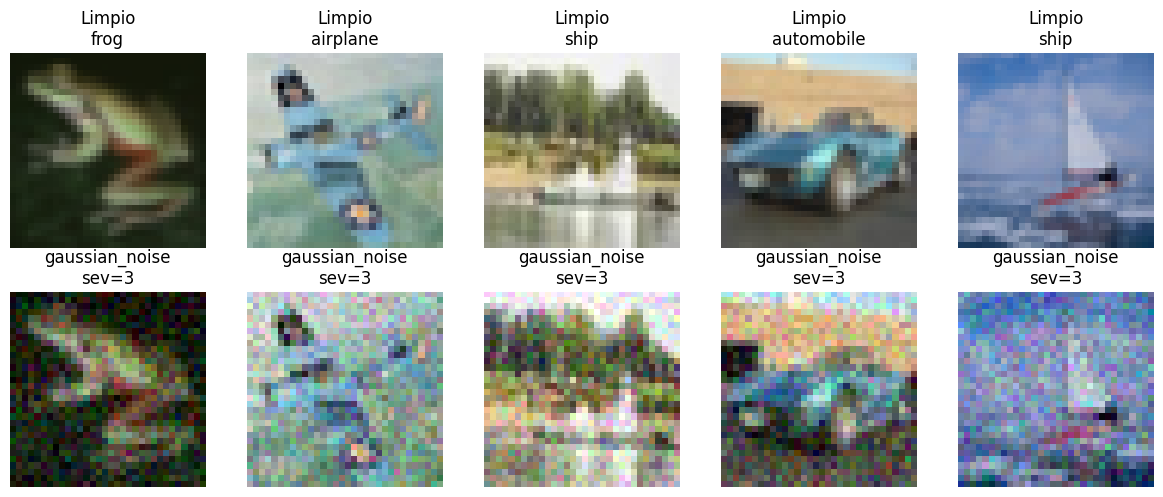

In [43]:
# Visualización rápida: limpio vs corrupto
idx = np.random.choice(len(X_test_clean), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, j in enumerate(idx):
    axes[0, i].imshow(X_test_clean[j]/255)
    axes[0, i].set_title(f"Limpio\n{class_names[y_test_clean[j]]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(X_test_corrupt[j]/255)
    axes[1, i].set_title(f"{corruption}\nsev={severity}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## Extracción de features

Para mantener el pipeline simple y clásico, usaremos:

- Hu Moments

Luego concatenamos ambas representaciones para entrenar un clasificador lineal.


In [44]:
from skimage.color import rgb2gray
from skimage.measure import moments_hu

def extract_features_hu_moments(images):
    hu_moments_list = []
    for img in images:
        # Convert image to grayscale and normalize
        gray = rgb2gray(img.astype(np.float32) / 255.0)
        # Calculate Hu moments
        hu_moments = moments_hu(gray)
        hu_moments_list.append(hu_moments)
    return np.array(hu_moments_list, dtype=np.float32)




In [46]:
n_train = 10000
n_test = 3000

Xtr = X_train[:n_train]
ytr = y_train[:n_train]

Xte_clean = X_test_clean[:n_test]
yte_clean = y_test_clean[:n_test]

Xte_corr = X_test_corrupt[:n_test]
yte_corr = y_test_corrupt[:n_test]

print("Extrayendo features de train...")
Ftr = extract_features_hu_moments(Xtr)

print("Extrayendo features de test limpio...")
Fte_clean = extract_features_hu_moments(Xte_clean)

print("Extrayendo features de test corrupto...")
Fte_corr = extract_features_hu_moments(Xte_corr)

print(Ftr.shape, Fte_clean.shape, Fte_corr.shape)


Extrayendo features de train...
Extrayendo features de test limpio...
Extrayendo features de test corrupto...
(10000, 7) (3000, 7) (3000, 7)


In [47]:
from xgboost import XGBClassifier

# Create an XGBoost pipeline
clf_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        objective='multi:softmax',
        num_class=len(class_names),
        eval_metric='merror',
        n_jobs=-1,
        random_state=42
    ))
])

print("Training XGBoost model...")
clf_xgb.fit(Ftr, ytr)

Training XGBoost model...


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='merror',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1, num_class=10, ...))])

In [48]:
pred_clean = clf_xgb.predict(Fte_clean)
pred_corr = clf_xgb.predict(Fte_corr)

acc_clean = accuracy_score(yte_clean, pred_clean)
acc_corr = accuracy_score(yte_corr, pred_corr)

print(f"Accuracy en test limpio:   {acc_clean:.4f}")
print(f"Accuracy en test corrupto: {acc_corr:.4f}")


Accuracy en test limpio:   0.1767
Accuracy en test corrupto: 0.1260


In [49]:
print("Reporte de clasificación en test limpio:")
print(classification_report(yte_clean, pred_clean, target_names=class_names))

Reporte de clasificación en test limpio:
              precision    recall  f1-score   support

    airplane       0.21      0.30      0.25       299
  automobile       0.17      0.13      0.15       287
        bird       0.14      0.14      0.14       318
         cat       0.18      0.15      0.16       295
        deer       0.18      0.20      0.19       299
         dog       0.16      0.14      0.15       290
        frog       0.12      0.12      0.12       307
       horse       0.17      0.14      0.16       286
        ship       0.19      0.20      0.19       316
       truck       0.23      0.23      0.23       303

    accuracy                           0.18      3000
   macro avg       0.17      0.18      0.17      3000
weighted avg       0.17      0.18      0.17      3000



In [50]:
print("Reporte de clasificación en test corrupto:")
print(classification_report(yte_corr, pred_corr, target_names=class_names))


Reporte de clasificación en test corrupto:
              precision    recall  f1-score   support

    airplane       0.14      0.06      0.08       299
  automobile       0.09      0.11      0.10       287
        bird       0.12      0.10      0.11       318
         cat       0.12      0.12      0.12       295
        deer       0.14      0.17      0.15       299
         dog       0.15      0.12      0.13       290
        frog       0.12      0.16      0.14       307
       horse       0.08      0.12      0.10       286
        ship       0.11      0.07      0.08       316
       truck       0.18      0.22      0.20       303

    accuracy                           0.13      3000
   macro avg       0.13      0.13      0.12      3000
weighted avg       0.13      0.13      0.12      3000



## Experimentos sugeridos

Prueba estas variaciones:

1. comparar otros tipos de features vs **combinación**;
2. aplicar un preprocesamiento previo:
   - ecualización de histograma,
   - suavizado,
   - corrección de contraste,
   - denoising;

## Preguntas para discusión
- ¿Qué features parecen más robustas al ruido?
- ¿La caída de accuracy es uniforme entre clases?
- ¿Qué preprocesamiento ayuda y cuál daña?
